

### 5.1.2 二维卷积算子

********

在本书后面的实现中，算子都继承`paddle.nn.Layer`，并使用支持反向传播的飞桨API进行实现，这样我们就可以不用手工写`backword()`的代码实现。

********

根据公式（5.1），我们首先实现一个简单的二维卷积算子，代码实现如下：

In [2]:
import paddle
import paddle.nn as nn
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np





class Conv2D(nn.Layer):
    def __init__(self, kernel_size, 
                    weight_attr=paddle.ParamAttr(initializer=nn.initializer.Assign(value=[[0., 1.],[2., 3.]]))):
        super(Conv2D, self).__init__()
        # 使用'paddle.create_parameter'创建卷积核
        # 使用'paddle.ParamAttr'进行参数初始化
        self.weight = paddle.create_parameter(shape=[kernel_size,kernel_size],
                                                dtype='float32',
                                                attr=weight_attr)
    def forward(self, X):
        """
        输入：
            - X：输入矩阵，shape=[B, M, N]，B为样本数量
        输出：
            - output：输出矩阵
        """
        u, v = self.weight.shape
        output = paddle.zeros([X.shape[0], X.shape[1] - u + 1, X.shape[2] - v + 1])
        for i in range(output.shape[1]):
            for j in range(output.shape[2]):
                output[:, i, j] = paddle.sum(X[:, i:i+u, j:j+v]*self.weight, axis=[1,2])
        return output

# 随机构造一个二维输入矩阵
paddle.seed(100)
inputs = paddle.to_tensor([[[1.,2.,3.],[4.,5.,6.],[7.,8.,9.]]])

conv2d = Conv2D(kernel_size=2)
outputs = conv2d(inputs)
print("input: {}, \noutput: {}".format(inputs, outputs))


input: Tensor(shape=[1, 3, 3], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[[1., 2., 3.],
         [4., 5., 6.],
         [7., 8., 9.]]]), 
output: Tensor(shape=[1, 2, 2], dtype=float32, place=Place(cpu), stop_gradient=False,
       [[[25., 31.],
         [43., 49.]]])


#### 5.1.5.2 零填充（Zero Padding）

在卷积运算中，还可以对输入用零进行填充使得其尺寸变大。根据卷积的定义，如果不进行填充，当卷积核尺寸大于1时，输出特征会缩减。对输入进行零填充则可以对卷积核的宽度和输出的大小进行独立的控制。

在二维卷积运算中，**零填充**（Zero Padding）是指在输入矩阵周围对称地补上$P$个$0$。**图5.7** 为使用零填充的示例。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/deae0e6e83ba48968b153a2cc549c5bc8fc86d78c224441fb2e5700f3fea76ac" width = "200"></center>
<center><br>图5.7：padding=1的零填充 </br></center>
<br></br>

对于一个输入矩阵$\mathbf X\in\Bbb{R}^{M\times N}$和一个滤波器$\mathbf W \in\Bbb{R}^{U\times V}$，，步长为$S$，对输入矩阵进行零填充，那么最终输出矩阵大小则为

$$M' = \frac{M + 2P - U}{S} + 1,（5.6）$$
$$N' = \frac{N + 2P - V}{S} + 1.（5.7）$$

引入步长和零填充后的卷积，参数量和计算量的统计方式与之前一致，参数量与卷积核的尺寸有关，为：$U\times V$，计算量与输出特征图和卷积核的尺寸有关，为：

$$FLOPs=M'\times N'\times U\times V=(\frac{M + 2P - U}{S} + 1)\times (\frac{N + 2P - V}{S} + 1)\times U\times V。（5.8）$$

一般常用的卷积有以下三类：

1. **窄卷积**：步长$S=1$，两端不补零$P=0$，卷积后输出尺寸为：

$$M' = M - U + 1,（5.9）$$
$$N' = N - V + 1.（5.10）$$

2. **宽卷积**：步长$S=1$，两端补零$P=U-1=V-1$，卷积后输出尺寸为：

$$M' = M + U - 1,（5.11）$$
$$N' = N + V - 1.（5.12）$$

3. **等宽卷积**：步长$S=1$，两端补零$P=\frac{(U-1)}{2}=\frac{(V-1)}{2}$，卷积后输出尺寸为：

$$M' = M,（5.13）$$
$$N' = N.（5.14）$$

通常情况下，在层数较深的卷积神经网络，比如：VGG、ResNet中，会使用等宽卷积保证输出特征图的大小不会随着层数的变深而快速缩减。例如：当卷积核的大小为$3\times 3$时，会将步长设置为$S=1$，两端补零$P=1$，此时，卷积后的输出尺寸就可以保持不变。在本章后续的案例中，会使用ResNet进行实验。

### 5.1.6 带步长和零填充的二维卷积算子

引入步长和零填充后，二维卷积算子代码实现如下：

In [14]:
class Conv2D(nn.Layer):
    def __init__(self, kernel_size, stride=1, padding=0, 
                    weight_attr=paddle.ParamAttr(initializer=nn.initializer.Constant(value=1.0))):
        super(Conv2D, self).__init__()
        self.weight = paddle.create_parameter(shape=[kernel_size,kernel_size], 
                                                dtype='float32', 
                                                attr=weight_attr)
        # 步长
        self.stride = stride
        # 零填充
        self.padding = padding

    def forward(self, X):
        # 零填充
        new_X = paddle.zeros([X.shape[0], X.shape[1]+2*self.padding, X.shape[2]+2*self.padding])
        new_X[:, self.padding:X.shape[1]+self.padding, self.padding:X.shape[2]+self.padding] = X
        u, v = self.weight.shape
        output_w = (new_X.shape[1] - u) // self.stride + 1
        output_h = (new_X.shape[2] - v) // self.stride + 1
        output = paddle.zeros([X.shape[0], output_w, output_h])
        for i in range(0, output.shape[1]):
            for j in range(0, output.shape[2]):
                output[:, i, j] = paddle.sum(
                    new_X[:, self.stride*i:self.stride*i+u, self.stride*j:self.stride*j+v]*self.weight,
                    axis=[1,2])
        return output

inputs = paddle.randn(shape=[2, 8, 8])
conv2d_padding = Conv2D(kernel_size=3, padding=1)
outputs = conv2d_padding(inputs)
print("When kernel_size=3, padding=1 stride=1, input's shape: {}, output's shape: {}".format(inputs.shape, outputs.shape))
conv2d_stride = Conv2D(kernel_size=3, stride=2, padding=1)
outputs = conv2d_stride(inputs)
print("When kernel_size=3, padding=1 stride=2, input's shape: {}, output's shape: {}".format(inputs.shape, outputs.shape))

When kernel_size=3, padding=1 stride=1, input's shape: [2, 8, 8], output's shape: [2, 8, 8]
When kernel_size=3, padding=1 stride=2, input's shape: [2, 8, 8], output's shape: [2, 4, 4]


从输出结果看出，使用$3\times3$大小卷积，`padding`为1，当`stride`=1时，模型的输出特征图可以与输入特征图保持一致；当`stride`=2时，输出特征图的宽和高都缩小一倍。



#### 5.2.1.2 多通道卷积层算子

根据上面的公式，多通道卷积卷积层的代码实现如下：

In [15]:
class Conv2D(nn.Layer):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0,
                    weight_attr=paddle.ParamAttr(initializer=nn.initializer.Constant(value=1.0)),
                    bias_attr=paddle.ParamAttr(initializer=nn.initializer.Constant(value=0.0))):
        super(Conv2D, self).__init__()
        # 创建卷积核
        self.weight = paddle.create_parameter(shape=[out_channels, in_channels, kernel_size,kernel_size],
                                                dtype='float32',
                                                attr=weight_attr)
        # 创建偏置
        self.bias = paddle.create_parameter(shape=[out_channels, 1],
                                                dtype='float32',
                                                attr=bias_attr)
        self.stride = stride
        self.padding = padding
        # 输入通道数
        self.in_channels = in_channels
        # 输出通道数
        self.out_channels = out_channels

    # 基础卷积运算
    def single_forward(self, X, weight):
        # 零填充
        new_X = paddle.zeros([X.shape[0], X.shape[1]+2*self.padding, X.shape[2]+2*self.padding])
        new_X[:, self.padding:X.shape[1]+self.padding, self.padding:X.shape[2]+self.padding] = X
        u, v = weight.shape
        output_w = (new_X.shape[1] - u) // self.stride + 1
        output_h = (new_X.shape[2] - v) // self.stride + 1
        output = paddle.zeros([X.shape[0], output_w, output_h])
        for i in range(0, output.shape[1]):
            for j in range(0, output.shape[2]):
                output[:, i, j] = paddle.sum(
                    new_X[:, self.stride*i:self.stride*i+u, self.stride*j:self.stride*j+v]*weight, 
                    axis=[1,2])
        return output

    def forward(self, inputs):
        """
        输入：
            - inputs：输入矩阵，shape=[B, D, M, N]
            - weights：P组二维卷积核，shape=[P, D, U, V]
            - bias：P个偏置，shape=[P, 1]
        """
        feature_maps = []
        # 进行多次多输入通道卷积运算
        p=0
        for w, b in zip(self.weight, self.bias): # P个(w,b),每次计算一个特征图Zp
            multi_outs = []
            # 循环计算每个输入特征图对应的卷积结果
            for i in range(self.in_channels):
                single = self.single_forward(inputs[:,i,:,:], w[i])
                multi_outs.append(single)
                # print("Conv2D in_channels:",self.in_channels,"i:",i,"single:",single.shape)
            # 将所有卷积结果相加
            feature_map = paddle.sum(paddle.stack(multi_outs), axis=0) + b #Zp
            feature_maps.append(feature_map)
            # print("Conv2D out_channels:",self.out_channels, "p:",p,"feature_map:",feature_map.shape)
            p+=1
        # 将所有Zp进行堆叠
        out = paddle.stack(feature_maps, 1) 
        return out

inputs = paddle.to_tensor([[[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
               [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]]])
conv2d = Conv2D(in_channels=2, out_channels=3, kernel_size=2)
print("inputs shape:",inputs.shape)
outputs = conv2d(inputs)
print("Conv2D outputs shape:",outputs.shape)

# 比较与paddle API运算结果
conv2d_paddle = nn.Conv2D(in_channels=2, out_channels=3, kernel_size=2,
                            weight_attr=paddle.ParamAttr(initializer=nn.initializer.Constant(value=1.0)),
                            bias_attr=paddle.ParamAttr(initializer=nn.initializer.Constant(value=0.0)))
outputs_paddle = conv2d_paddle(inputs)
# 自定义算子运算结果
print('Conv2D outputs:', outputs)
# paddle API运算结果
print('nn.Conv2D outputs:', outputs_paddle)

inputs shape: [1, 2, 3, 3]
Conv2D outputs shape: [1, 3, 2, 2]
Conv2D outputs: Tensor(shape=[1, 3, 2, 2], dtype=float32, place=Place(gpu:0), stop_gradient=False,
       [[[[20., 28.],
          [44., 52.]],

         [[20., 28.],
          [44., 52.]],

         [[20., 28.],
          [44., 52.]]]])
nn.Conv2D outputs: Tensor(shape=[1, 3, 2, 2], dtype=float32, place=Place(gpu:0), stop_gradient=False,
       [[[[20., 28.],
          [44., 52.]],

         [[20., 28.],
          [44., 52.]],

         [[20., 28.],
          [44., 52.]]]])



**汇聚层的参数量和计算量**

由于汇聚层中没有参数，所以参数量为$0$；最大汇聚中，没有乘加运算，所以计算量为$0$，而平均汇聚中，输出特征图上每个点都对应了一次求平均运算。

使用飞桨实现一个简单的汇聚层，代码实现如下：

In [16]:
class Pool2D(nn.Layer):
    def __init__(self, size=(2,2), mode='max', stride=1):
        super(Pool2D, self).__init__()
        # 汇聚方式
        self.mode = mode
        self.h, self.w = size
        self.stride = stride

    def forward(self, x):
        output_w = (x.shape[2] - self.w) // self.stride + 1
        output_h = (x.shape[3] - self.h) // self.stride + 1
        output = paddle.zeros([x.shape[0], x.shape[1], output_w, output_h])
        # 汇聚
        for i in range(output.shape[2]):
            for j in range(output.shape[3]):
                # 最大汇聚
                if self.mode == 'max':
                    output[:, :, i, j] = paddle.max(
                        x[:, :, self.stride*i:self.stride*i+self.w, self.stride*j:self.stride*j+self.h], 
                        axis=[2,3])
                # 平均汇聚
                elif self.mode == 'avg':
                    output[:, :, i, j] = paddle.mean(
                        x[:, :, self.stride*i:self.stride*i+self.w, self.stride*j:self.stride*j+self.h], 
                        axis=[2,3])
        
        return output

inputs = paddle.to_tensor([[[[1.,2.,3.,4.],[5.,6.,7.,8.],[9.,10.,11.,12.],[13.,14.,15.,16.]]]])
pool2d = Pool2D(stride=2)
outputs = pool2d(inputs)
print("input: {}, \noutput: {}".format(inputs.shape, outputs.shape))

# 比较Maxpool2D与paddle API运算结果
maxpool2d_paddle = nn.MaxPool2D(kernel_size=(2,2), stride=2)
outputs_paddle = maxpool2d_paddle(inputs)
# 自定义算子运算结果
print('Maxpool2D outputs:', outputs)
# paddle API运算结果
print('nn.Maxpool2D outputs:', outputs_paddle)

# 比较Avgpool2D与paddle API运算结果
avgpool2d_paddle = nn.AvgPool2D(kernel_size=(2,2), stride=2)
outputs_paddle = avgpool2d_paddle(inputs)
pool2d = Pool2D(mode='avg', stride=2)
outputs = pool2d(inputs)
# 自定义算子运算结果
print('Avgpool2D outputs:', outputs)
# paddle API运算结果
print('nn.Avgpool2D outputs:', outputs_paddle)

input: [1, 1, 4, 4], 
output: [1, 1, 2, 2]
Maxpool2D outputs: Tensor(shape=[1, 1, 2, 2], dtype=float32, place=Place(gpu:0), stop_gradient=True,
       [[[[6. , 8. ],
          [14., 16.]]]])
nn.Maxpool2D outputs: Tensor(shape=[1, 1, 2, 2], dtype=float32, place=Place(gpu:0), stop_gradient=True,
       [[[[6. , 8. ],
          [14., 16.]]]])
Avgpool2D outputs: Tensor(shape=[1, 1, 2, 2], dtype=float32, place=Place(gpu:0), stop_gradient=True,
       [[[[3.50000000 , 5.50000000 ],
          [11.50000000, 13.50000000]]]])
nn.Avgpool2D outputs: Tensor(shape=[1, 1, 2, 2], dtype=float32, place=Place(gpu:0), stop_gradient=True,
       [[[[3.50000000 , 5.50000000 ],
          [11.50000000, 13.50000000]]]])


为了节省训练时间，本节选取MNIST数据集的一个子集进行后续实验，数据集的划分为：

* 训练集：1,000条样本
* 验证集：200条样本
* 测试集：200条样本

MNIST数据集分为train_set、dev_set和test_set三个数据集，每个数据集含两个列表分别存放了图片数据以及标签数据。比如train_set包含：

* **图片数据**：[1 000, 784]的二维列表，包含1 000张图片。每张图片用一个长度为784的向量表示，内容是 $28\times 28$ 尺寸的像素灰度值（黑白图片）。
* **标签数据**：[1 000, 1]的列表，表示这些图片对应的分类标签，即0~9之间的数字。

观察数据集分布情况，代码实现如下：

In [17]:
import json
import gzip

# 打印并观察数据集分布情况
train_set, dev_set, test_set = json.load(gzip.open('./mnist.json.gz'))
train_images, train_labels = train_set[0][:1000], train_set[1][:1000]
dev_images, dev_labels = dev_set[0][:200], dev_set[1][:200]
test_images, test_labels = test_set[0][:200], test_set[1][:200]
train_set, dev_set, test_set = [train_images, train_labels], [dev_images, dev_labels], [test_images, test_labels]
print('Length of train/dev/test set:{}/{}/{}'.format(len(train_set[0]), len(dev_set[0]), len(test_set[0])))

Length of train/dev/test set:1000/200/200


可视化观察其中的一张样本以及对应的标签，代码如下所示：

The number in the picture is 5


/tmp/ipykernel_49966/3048091050.py:5: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image.astype('uint8'), mode='L')


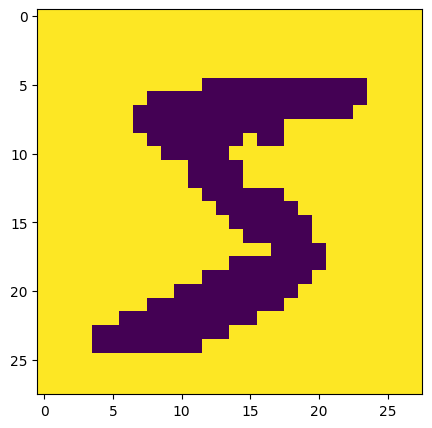

In [18]:
image, label = train_set[0][0], train_set[1][0]
image, label = np.array(image).astype('float32'), int(label)
# 原始图像数据为长度784的行向量，需要调整为[28,28]大小的图像
image = np.reshape(image, [28,28])
image = Image.fromarray(image.astype('uint8'), mode='L')
print("The number in the picture is {}".format(label))
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.savefig('conv-number5.pdf')

#### 5.3.1.1 数据预处理

图像分类网络对输入图片的格式、大小有一定的要求，数据输入模型前，需要对数据进行预处理操作，使图片满足网络训练以及预测的需要。本实验主要应用了如下方法：

*  调整图片大小：LeNet网络对输入图片大小的要求为 $32\times 32$ ，而MNIST数据集中的原始图片大小却是 $28\times 28$ ，这里为了符合网络的结构设计，将其调整为$32 \times 32$；
*  规范化： 通过规范化手段，把输入图像的分布改变成均值为0，标准差为1的标准正态分布，使得最优解的寻优过程明显会变得平缓，训练过程更容易收敛。

*******

在飞桨中，提供了部分视觉领域的高层API，可以直接调用API实现简单的图像处理操作。通过调用`paddle.vision.transforms.Resize`调整大小；调用`paddle.vision.transforms.Normalize`进行标准化处理；使用`paddle.vision.transforms.Compose`将两个预处理操作进行拼接。

*******

代码实现如下：

In [19]:
from paddle.vision.transforms import Compose, Resize, Normalize

# 数据预处理
transforms = Compose([Resize(32), Normalize(mean=[127.5], std=[127.5], data_format='CHW')])

将原始的数据集封装为Dataset类，以便DataLoader调用。

In [20]:
import random
import paddle.io as io

class MNIST_dataset(io.Dataset):
    def __init__(self, dataset, transforms, mode='train'):
        self.mode = mode
        self.transforms =transforms
        self.dataset = dataset

    def __getitem__(self, idx):
        # 获取图像和标签
        image, label = self.dataset[0][idx], self.dataset[1][idx]
        image, label = np.array(image).astype('float32'), int(label)
        image = np.reshape(image, [28,28])
        image = Image.fromarray(image.astype('uint8'), mode='L')
        image = self.transforms(image)

        return image, label

    def __len__(self):
        return len(self.dataset[0])

In [21]:
# 固定随机种子
random.seed(0)
# 加载 mnist 数据集
train_dataset = MNIST_dataset(dataset=train_set, transforms=transforms, mode='train')
test_dataset = MNIST_dataset(dataset=test_set, transforms=transforms, mode='test')
dev_dataset = MNIST_dataset(dataset=dev_set, transforms=transforms, mode='dev')

### 5.3.2 模型构建

LeNet-5虽然提出的时间比较早，但它是一个非常成功的神经网络模型。基于LeNet-5的手写数字识别系统在20世纪90年代被美国很多银行使用，用来识别支票上面的手写数字。LeNet-5的网络结构如**图5.13**所示。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/448b1f120a2e4890bae4589d213c0ab36f71b8d9d6204998a6cceddaabbe9ab5" width="600" hegiht="" ></center>
<center><br>图5.13：LeNet-5网络结构</br></center>
<br></br>

我们使用上面定义的卷积层算子和汇聚层算子构建一个LeNet-5模型。

************

  这里的LeNet-5和原始版本有4点不同：
1. C3层没有使用连接表来减少卷积数量。
1. 汇聚层使用了简单的平均汇聚，没有引入权重和偏置参数以及非线性激活函数。
1. 卷积层的激活函数使用ReLU函数。
1. 最后的输出层为一个全连接线性层。

************

网络共有7层，包含3个卷积层、2个汇聚层以及2个全连接层的简单卷积神经网络接，受输入图像大小为$32\times 32=1\, 024$，输出对应10个类别的得分。
具体实现如下：

In [31]:
import paddle.nn.functional as F

class Model_LeNet(nn.Layer):
    def __init__(self, in_channels, num_classes=10):
        super(Model_LeNet, self).__init__()
        # 卷积层：输出通道数为6，卷积核大小为5×5
        self.conv1 = Conv2D(in_channels=in_channels, out_channels=6, kernel_size=5, weight_attr=paddle.ParamAttr())
        # 汇聚层：汇聚窗口为2×2，步长为2
        self.pool2 = Pool2D(size=(2,2), mode='max', stride=2)
        # 卷积层：输入通道数为6，输出通道数为16，卷积核大小为5×5，步长为1
        self.conv3 = Conv2D(in_channels=6, out_channels=16, kernel_size=5, stride=1, weight_attr=paddle.ParamAttr())
        # 汇聚层：汇聚窗口为2×2，步长为2
        self.pool4 = Pool2D(size=(2,2), mode='avg', stride=2)
        # 卷积层：输入通道数为16，输出通道数为120，卷积核大小为5×5
        self.conv5 = Conv2D(in_channels=16, out_channels=120, kernel_size=5, stride=1, weight_attr=paddle.ParamAttr())
        # 全连接层：输入神经元为120，输出神经元为84
        self.linear6 = nn.Linear(120, 84)
        # 全连接层：输入神经元为84，输出神经元为类别数
        self.linear7 = nn.Linear(84, num_classes)

    def forward(self, x):
        # C1：卷积层+激活函数
        output = F.relu(self.conv1(x))
        # S2：汇聚层
        output = self.pool2(output)
        # C3：卷积层+激活函数
        output = F.relu(self.conv3(output))
        # S4：汇聚层
        output = self.pool4(output)
        # C5：卷积层+激活函数
        output = F.relu(self.conv5(output))
        # 输入层将数据拉平[B,C,H,W] -> [B,CxHxW]
        output = paddle.squeeze(output, axis=[2,3])
        # F6：全连接层
        output = F.relu(self.linear6(output))
        # F7：全连接层
        output = self.linear7(output)
        return output

下面测试一下上面的LeNet-5模型，构造一个形状为 [1,1,32,32]的输入数据送入网络，观察每一层特征图的形状变化。代码实现如下：

In [32]:
# 这里用np.random创建一个随机数组作为输入数据
inputs = np.random.randn(*[1,1,32,32])
inputs = inputs.astype('float32')

# 创建Model_LeNet类的实例，指定模型名称和分类的类别数目
model = Model_LeNet(in_channels=1, num_classes=10)
# 通过调用LeNet从基类继承的sublayers()函数，查看LeNet中所包含的子层
print(model.sublayers())
x = paddle.to_tensor(inputs)
for item in model.sublayers():
    # item是LeNet类中的一个子层
    # 查看经过子层之后的输出数据形状
    try:
        x = item(x)
    except:
        # 如果是最后一个卷积层输出，需要展平后才可以送入全连接层
        x = paddle.reshape(x, [x.shape[0], -1])
        x = item(x)
    if len(item.parameters())==2:
        # 查看卷积和全连接层的数据和参数的形状，
        # 其中item.parameters()[0]是权重参数w，item.parameters()[1]是偏置参数b
        print(item.full_name(), x.shape, item.parameters()[0].shape, 
                item.parameters()[1].shape)
    else:
        # 汇聚层没有参数
        print(item.full_name(), x.shape)

[Conv2D(), Pool2D(), Conv2D(), Pool2D(), Conv2D(), Linear(in_features=120, out_features=84, dtype=float32), Linear(in_features=84, out_features=10, dtype=float32)]
conv2d_34 [1, 6, 28, 28] [6, 1, 5, 5] [6, 1]
pool2d_14 [1, 6, 14, 14]
conv2d_35 [1, 16, 10, 10] [16, 6, 5, 5] [16, 1]
pool2d_15 [1, 16, 5, 5]
conv2d_36 [1, 120, 1, 1] [120, 16, 5, 5] [120, 1]
linear_16 [1, 84] [120, 84] [84]
linear_17 [1, 10] [84, 10] [10]


从输出结果看，
* 对于大小为$32 \times32$的单通道图像，先用6个大小为$5 \times5$的卷积核对其进行卷积运算，输出为6个$28 \times28$大小的特征图；
* 6个$28 \times28$大小的特征图经过大小为$2 \times2$，步长为2的汇聚层后，输出特征图的大小变为$14 \times14$；
* 6个$14 \times14$大小的特征图再经过16个大小为$5 \times5$的卷积核对其进行卷积运算，得到16个$10 \times10$大小的输出特征图；
* 16个$10 \times10$大小的特征图经过大小为$2 \times2$，步长为2的汇聚层后，输出特征图的大小变为$5 \times5$；
* 16个$5 \times5$大小的特征图再经过120个大小为$5 \times5$的卷积核对其进行卷积运算，得到120个$1 \times1$大小的输出特征图；
* 此时，将特征图展平成1维，则有120个像素点，经过输入神经元个数为120，输出神经元个数为84的全连接层后，输出的长度变为84。
* 再经过一个全连接层的计算，最终得到了长度为类别数的输出结果。

考虑到自定义的`Conv2D`和`Pool2D`算子中包含多个`for`循环，所以运算速度比较慢。飞桨框架中，针对卷积层算子和汇聚层算子进行了速度上的优化，这里基于`paddle.nn.Conv2D`、`paddle.nn.MaxPool2D`和`paddle.nn.AvgPool2D`构建LeNet-5模型，对比与上边实现的模型的运算速度。代码实现如下：

In [33]:
class Paddle_LeNet(nn.Layer):
    def __init__(self, in_channels, num_classes=10):
        super(Paddle_LeNet, self).__init__()
        # 卷积层：输出通道数为6，卷积核大小为5*5
        self.conv1 = nn.Conv2D(in_channels=in_channels, out_channels=6, kernel_size=5)
        # 汇聚层：汇聚窗口为2*2，步长为2
        self.pool2 = nn.MaxPool2D(kernel_size=2, stride=2)
        # 卷积层：输入通道数为6，输出通道数为16，卷积核大小为5*5
        self.conv3 = nn.Conv2D(in_channels=6, out_channels=16, kernel_size=5)
        # 汇聚层：汇聚窗口为2*2，步长为2
        self.pool4 = nn.AvgPool2D(kernel_size=2, stride=2)
        # 卷积层：输入通道数为16，输出通道数为120，卷积核大小为5*5
        self.conv5 = nn.Conv2D(in_channels=16, out_channels=120, kernel_size=5)
        # 全连接层：输入神经元为120，输出神经元为84
        self.linear6 = nn.Linear(in_features=120, out_features=84)
        # 全连接层：输入神经元为84，输出神经元为类别数
        self.linear7 = nn.Linear(in_features=84, out_features=num_classes)

    def forward(self, x):
        # C1：卷积层+激活函数
        output = F.relu(self.conv1(x))
        # S2：汇聚层
        output = self.pool2(output)
        # C3：卷积层+激活函数
        output = F.relu(self.conv3(output))
        # S4：汇聚层
        output = self.pool4(output)
        # C5：卷积层+激活函数
        output = F.relu(self.conv5(output))
        # 输入层将数据拉平[B,C,H,W] -> [B,CxHxW]
        output = paddle.squeeze(output, axis=[2,3])
        # F6：全连接层
        output = F.relu(self.linear6(output))
        # F7：全连接层
        output = self.linear7(output)
        return output

测试两个网络的运算速度。

In [34]:
import time

# 这里用np.random创建一个随机数组作为测试数据
inputs = np.random.randn(*[1,1,32,32])
inputs = inputs.astype('float32')
x = paddle.to_tensor(inputs)

# 创建Model_LeNet类的实例，指定模型名称和分类的类别数目
model = Model_LeNet(in_channels=1, num_classes=10)
# 创建Paddle_LeNet类的实例，指定模型名称和分类的类别数目
paddle_model = Paddle_LeNet(in_channels=1, num_classes=10)

# 计算Model_LeNet类的运算速度
model_time = 0
for i in range(60):
    strat_time = time.time()
    out = model(x)
    end_time = time.time()
    # 预热10次运算，不计入最终速度统计
    if i < 10:
        continue
    model_time += (end_time - strat_time)
avg_model_time = model_time / 50
print('Model_LeNet speed:', avg_model_time, 's')

# 计算Paddle_LeNet类的运算速度
paddle_model_time = 0
for i in range(60):
    strat_time = time.time()
    paddle_out = paddle_model(x)
    end_time = time.time()
    # 预热10次运算，不计入最终速度统计
    if i < 10:
        continue
    paddle_model_time += (end_time - strat_time)
avg_paddle_model_time = paddle_model_time / 50

print('Paddle_LeNet speed:', avg_paddle_model_time, 's')

Model_LeNet speed: 1.392316584587097 s
Paddle_LeNet speed: 0.0006069517135620117 s


这里还可以令两个网络加载同样的权重，测试一下两个网络的输出结果是否一致。

In [35]:
# 这里用np.random创建一个随机数组作为测试数据
inputs = np.random.randn(*[1,1,32,32])
inputs = inputs.astype('float32')
x = paddle.to_tensor(inputs)

# 创建Model_LeNet类的实例，指定模型名称和分类的类别数目
model = Model_LeNet(in_channels=1, num_classes=10)
# 获取网络的权重
params = model.state_dict()
# 自定义Conv2D算子的bias参数形状为[out_channels, 1]
# paddle API中Conv2D算子的bias参数形状为[out_channels]
# 需要进行调整后才可以赋值
for key in params:
    if 'bias' in key:
        params[key] = params[key].squeeze()
# 创建Paddle_LeNet类的实例，指定模型名称和分类的类别数目
paddle_model = Paddle_LeNet(in_channels=1, num_classes=10)
# 将Model_LeNet的权重参数赋予给Paddle_LeNet模型，保持两者一致
paddle_model.set_state_dict(params)

# 打印结果保留小数点后6位
paddle.set_printoptions(6)
# 计算Model_LeNet的结果
output = model(x)
print('Model_LeNet output: ', output)
# 计算Paddle_LeNet的结果
paddle_output = paddle_model(x)
print('Paddle_LeNet output: ', paddle_output)

Model_LeNet output:  Tensor(shape=[1, 10], dtype=float32, place=Place(gpu:0), stop_gradient=False,
       [[-0.240407, -0.016904,  0.054156,  0.021071,  0.130889,  0.131362,
          0.034776, -0.054051, -0.005055, -0.010174]])
Paddle_LeNet output:  Tensor(shape=[1, 10], dtype=float32, place=Place(gpu:0), stop_gradient=False,
       [[-0.240407, -0.016903,  0.054156,  0.021071,  0.130889,  0.131362,
          0.034776, -0.054051, -0.005055, -0.010174]])


可以看到，输出结果是一致的。

这里还可以统计一下LeNet-5模型的参数量和计算量。

**参数量**

按照公式(5.18)进行计算，可以得到：
* 第一个卷积层的参数量为：$6 \times 1 \times 5 \times 5 + 6 = 156$；
* 第二个卷积层的参数量为：$16 \times 6 \times 5 \times 5 + 16 = 2416$；
* 第三个卷积层的参数量为：$120 \times 16 \times 5 \times 5 + 120= 48120$；
* 第一个全连接层的参数量为：$120 \times 84 + 84= 10164$；
* 第二个全连接层的参数量为：$84 \times 10 + 10= 850$；

所以，LeNet-5总的参数量为$61706$。

在飞桨中，还可以使用`paddle.summary`API自动计算参数量。

In [36]:
model = Paddle_LeNet(in_channels=1, num_classes=10)
params_info = paddle.summary(model, (1, 1, 32, 32))
print(params_info)

---------------------------------------------------------------------------
 Layer (type)       Input Shape          Output Shape         Param #    
   Conv2D-50      [[1, 1, 32, 32]]      [1, 6, 28, 28]          156      
  MaxPool2D-8     [[1, 6, 28, 28]]      [1, 6, 14, 14]           0       
   Conv2D-51      [[1, 6, 14, 14]]     [1, 16, 10, 10]         2,416     
  AvgPool2D-8    [[1, 16, 10, 10]]      [1, 16, 5, 5]            0       
   Conv2D-52      [[1, 16, 5, 5]]       [1, 120, 1, 1]        48,120     
   Linear-27         [[1, 120]]            [1, 84]            10,164     
   Linear-28         [[1, 84]]             [1, 10]              850      
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
---------------------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.24
Estimated Total Size (MB): 0.30
-----------------------------------------------------------------------

可以看到，结果与公式推导一致。

**计算量**

按照公式(5.19)进行计算，可以得到：
* 第一个卷积层的计算量为：$28\times 28\times 5\times 5\times 6\times 1 + 28\times 28\times 6=122304$；
* 第二个卷积层的计算量为：$10\times 10\times 5\times 5\times 16\times 6 + 10\times 10\times 16=241600$；
* 第三个卷积层的计算量为：$1\times 1\times 5\times 5\times 120\times 16 + 1\times 1\times 120=48120$；
* 平均汇聚层的计算量为：$16\times 5\times 5=400$
* 第一个全连接层的计算量为：$120 \times 84 = 10080$；
* 第二个全连接层的计算量为：$84 \times 10 = 840$；

所以，LeNet-5总的计算量为$423344$。

在飞桨中，还可以使用`paddle.flops`API自动统计计算量。

In [37]:
FLOPs = paddle.flops(model, (1, 1, 32, 32), print_detail=True)
print(FLOPs)

<class 'paddle.nn.layer.conv.Conv2D'>'s flops has been counted
Cannot find suitable count function for <class 'paddle.nn.layer.pooling.MaxPool2D'>. Treat it as zero FLOPs.
<class 'paddle.nn.layer.pooling.AvgPool2D'>'s flops has been counted
<class 'paddle.nn.layer.common.Linear'>'s flops has been counted
+--------------+-----------------+-----------------+--------+--------+
|  Layer Name  |   Input Shape   |   Output Shape  | Params | Flops  |
+--------------+-----------------+-----------------+--------+--------+
|  conv2d_49   |  [1, 1, 32, 32] |  [1, 6, 28, 28] |  156   | 122304 |
| max_pool2d_7 |  [1, 6, 28, 28] |  [1, 6, 14, 14] |   0    |   0    |
|  conv2d_50   |  [1, 6, 14, 14] | [1, 16, 10, 10] |  2416  | 241600 |
| avg_pool2d_7 | [1, 16, 10, 10] |  [1, 16, 5, 5]  |   0    |  400   |
|  conv2d_51   |  [1, 16, 5, 5]  |  [1, 120, 1, 1] | 48120  | 48120  |
|  linear_26   |     [1, 120]    |     [1, 84]     | 10164  | 10080  |
|  linear_27   |     [1, 84]     |     [1, 10]     |  8

可以看到，结果与公式推导一致。

### 5.3.3 模型训练

使用交叉熵损失函数，并用随机梯度下降法作为优化器来训练LeNet-5网络。
用RunnerV3在训练集上训练5个epoch，并保存准确率最高的模型作为最佳模型。

In [42]:
import paddle.optimizer as opt
from nndl import RunnerV3
from nndl import metric as metric_module
import importlib

importlib.reload(metric_module)
paddle.seed(100)
# 学习率大小
lr = 0.1    
# 批次大小
batch_size = 64
# 加载数据
train_loader = io.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = io.DataLoader(dev_dataset, batch_size=batch_size)
test_loader = io.DataLoader(test_dataset, batch_size=batch_size)
# 定义LeNet网络
# 自定义算子实现的LeNet-5
model = Model_LeNet(in_channels=1, num_classes=10)
# 飞桨API实现的LeNet-5
# model = Paddle_LeNet(in_channels=1, num_classes=10)
# 定义优化器
optimizer = opt.SGD(learning_rate=lr, parameters=model.parameters())
# 定义损失函数
loss_fn = F.cross_entropy
# 定义评价指标
# metric = metric.Accuracy(is_logist=True)

acc = metric_module.Accuracy(is_logist=True)
# 实例化 RunnerV3 类，并传入训练配置。
runner = RunnerV3(model, optimizer, loss_fn, acc)
# 启动训练
log_steps = 15
eval_steps = 15
runner.train(train_loader, dev_loader, num_epochs=5, log_steps=log_steps, 
                eval_steps=eval_steps, save_path="best_model.pdparams")          

/tmp/ipykernel_49966/4050099145.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image.astype('uint8'), mode='L')


[Train] epoch: 0/5, step: 0/80, loss: 2.29819
[Train] epoch: 0/5, step: 15/80, loss: 2.14581
[Evaluate]  dev score: 0.43000, dev loss: 2.14163
[Evaluate] best accuracy performence has been updated: 0.00000 --> 0.43000
[Train] epoch: 1/5, step: 30/80, loss: 1.40552
[Evaluate]  dev score: 0.40500, dev loss: 1.74635
[Train] epoch: 2/5, step: 45/80, loss: 0.57702
[Evaluate]  dev score: 0.73000, dev loss: 0.72735
[Evaluate] best accuracy performence has been updated: 0.43000 --> 0.73000
[Train] epoch: 3/5, step: 60/80, loss: 0.52141
[Evaluate]  dev score: 0.69500, dev loss: 0.77848
[Train] epoch: 4/5, step: 75/80, loss: 0.27878
[Evaluate]  dev score: 0.84000, dev loss: 0.41385
[Evaluate] best accuracy performence has been updated: 0.73000 --> 0.84000
[Evaluate]  dev score: 0.79500, dev loss: 0.57127
[Train] Training done!


可视化观察训练集与验证集的损失变化情况。

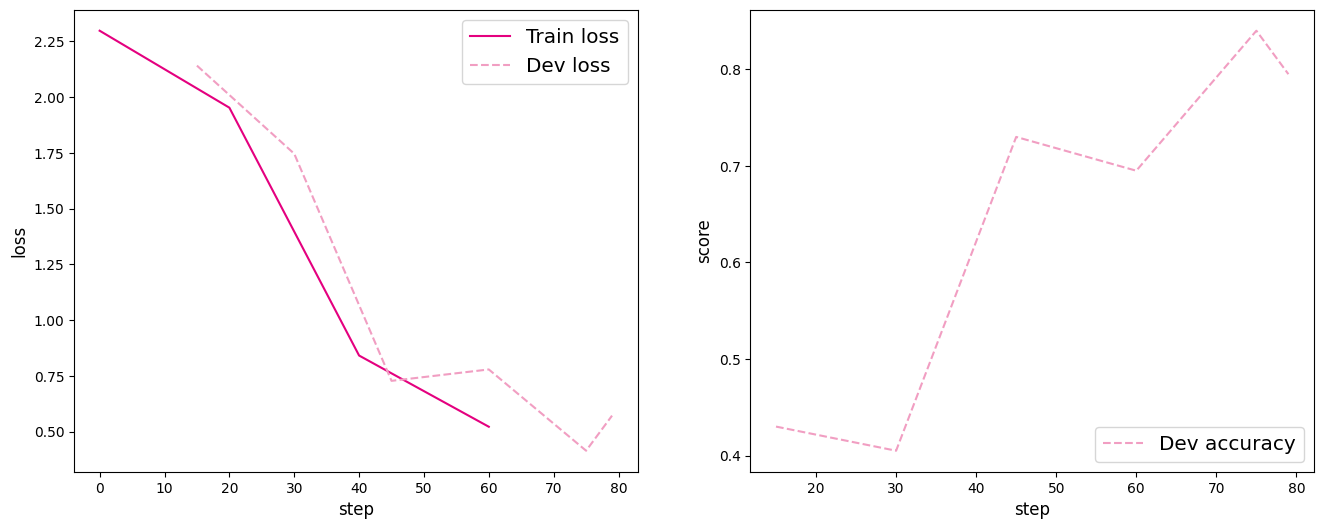

In [43]:
from nndl import plot_training_loss_acc
plot_training_loss_acc(runner, 'cnn-loss1.pdf')

### 5.3.4 模型评价

使用测试数据对在训练过程中保存的最佳模型进行评价，观察模型在测试集上的准确率以及损失变化情况。

In [44]:
# 加载最优模型
runner.load_model('best_model.pdparams')
# 模型评价
score, loss = runner.evaluate(test_loader)
print("[Test] accuracy/loss: {:.4f}/{:.4f}".format(score, loss))

/tmp/ipykernel_49966/4050099145.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image.astype('uint8'), mode='L')


[Test] accuracy/loss: 0.8850/0.4881


### 5.3.5 模型预测

同样地，我们也可以使用保存好的模型，对测试集中的某一个数据进行模型预测，观察模型效果。

/tmp/ipykernel_49966/4050099145.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image.astype('uint8'), mode='L')


The true category is 7 and the predicted category is 7


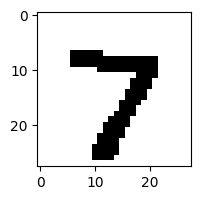

In [54]:
# 获取测试集第一个 batch
X, labels = next(iter(test_loader))  # 注意 iter() 才能用 next()

# 模型预测
logits = runner.predict(X)
pred = F.softmax(logits, axis=1)    # 多分类用 axis=1
pred_class = paddle.argmax(pred[0]).item()  # 第一个样本预测类别
true_label = labels[0].item()                # 第一个样本真实标签

print(f"The true category is {true_label} and the predicted category is {pred_class}")

# 可视化测试集第一张图像
# test_set[0] 是包含所有图像的 list，取第一个样本
image_flat = test_set[0][0]                    # 第一个 batch 的第一个样本
image = np.array(image_flat, dtype='float32').reshape(28,28)

plt.figure(figsize=(2,2))
plt.imshow(Image.fromarray(image.astype('uint8')), cmap='gray')
plt.savefig('cnn-number2.pdf')
plt.show()


## 5.4 基于残差网络的手写体数字识别实验

**残差网络**（Residual Network，ResNet）是在神经网络模型中给非线性层增加直连边的方式来缓解梯度消失问题，从而使训练深度神经网络变得更加容易。

在残差网络中，最基本的单位为**残差单元**。

假设$f(\mathbf x;\theta)$为一个或多个神经层，残差单元在$f()$的输入和输出之间加上一个**直连边**。

不同于传统网络结构中让网络$f(x;\theta)$去逼近一个目标函数$h(x)$，在残差网络中，将目标函数$h(x)$拆为了两个部分：恒等函数$x$和残差函数$h(x)-x$

$$
\mathrm{ResBlock}_f(\mathbf x) = f(\mathbf x;\theta) + \mathbf x,（5.22）
$$

其中$\theta$为可学习的参数。

一个典型的残差单元如**图5.14**所示，由多个级联的卷积层和一个跨层的直连边组成。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/cf14626bb6c54eb9840a7253975fdc995f165146c6324bdb8f9b943b96f57394" width = "200"></center>
<center><br>图5.14：残差单元结构</br></center>


一个残差网络通常有很多个残差单元堆叠而成。下面我们来构建一个在计算机视觉中非常典型的残差网络：ResNet18，并重复上一节中的手写体数字识别任务。

### 5.4.1 模型构建

在本节中，我们先构建ResNet18的残差单元，然后在组建完整的网络。

#### 5.4.1.1 残差单元

这里，我们实现一个算子`ResBlock`来构建残差单元，其中定义了`use_residual`参数，用于在后续实验中控制是否使用残差连接。


*******

残差单元包裹的非线性层的输入和输出形状大小应该一致。如果一个卷积层的输入特征图和输出特征图的通道数不一致，则其输出与输入特征图无法直接相加。为了解决上述问题，我们可以使用$1 \times 1$大小的卷积将输入特征图的通道数映射为与级联卷积输出特征图的一致通道数。

$1 \times 1$卷积：与标准卷积完全一样，唯一的特殊点在于卷积核的尺寸是$1 \times 1$，也就是不去考虑输入数据局部信息之间的关系，而把关注点放在不同通道间。通过使用$1 \times 1$卷积，可以起到如下作用：

* 实现信息的跨通道交互与整合。考虑到卷积运算的输入输出都是3个维度（宽、高、多通道），所以$1 \times 1$卷积实际上就是对每个像素点，在不同的通道上进行线性组合，从而整合不同通道的信息；
* 对卷积核通道数进行降维和升维，减少参数量。经过$1 \times 1$卷积后的输出保留了输入数据的原有平面结构，通过调控通道数，从而完成升维或降维的作用；
* 利用$1 \times 1$卷积后的非线性激活函数，在保持特征图尺寸不变的前提下，大幅增加非线性。

*******

In [55]:
class ResBlock(nn.Layer):
    def __init__(self, in_channels, out_channels, stride=1, use_residual=True):
        """
        残差单元
        输入：
            - in_channels：输入通道数
            - out_channels：输出通道数
            - stride：残差单元的步长，通过调整残差单元中第一个卷积层的步长来控制
            - use_residual：用于控制是否使用残差连接
        """
        super(ResBlock, self).__init__()
        self.stride = stride
        self.use_residual = use_residual
        # 第一个卷积层，卷积核大小为3×3，可以设置不同输出通道数以及步长
        self.conv1 = nn.Conv2D(in_channels, out_channels, 3, padding=1, stride=self.stride, bias_attr=False)
        # 第二个卷积层，卷积核大小为3×3，不改变输入特征图的形状，步长为1
        self.conv2 = nn.Conv2D(out_channels, out_channels, 3, padding=1, bias_attr=False)
        
        # 如果conv2的输出和此残差块的输入数据形状不一致，则use_1x1conv = True
        # 当use_1x1conv = True，添加1个1x1的卷积作用在输入数据上，使其形状变成跟conv2一致
        if in_channels != out_channels or stride != 1:
            self.use_1x1conv = True
        else:
            self.use_1x1conv = False
        # 当残差单元包裹的非线性层输入和输出通道数不一致时，需要用1×1卷积调整通道数后再进行相加运算
        if self.use_1x1conv:
            self.shortcut = nn.Conv2D(in_channels, out_channels, 1, stride=self.stride, bias_attr=False)

        # 每个卷积层后会接一个批量规范化层，批量规范化的内容在7.5.1中会进行详细介绍
        self.bn1 = nn.BatchNorm2D(out_channels)
        self.bn2 = nn.BatchNorm2D(out_channels)
        if self.use_1x1conv:
            self.bn3 = nn.BatchNorm2D(out_channels)

    def forward(self, inputs):
        y = F.relu(self.bn1(self.conv1(inputs)))
        y = self.bn2(self.conv2(y))
        if self.use_residual:
            if self.use_1x1conv:  # 如果为真，对inputs进行1×1卷积，将形状调整成跟conv2的输出y一致
                shortcut = self.shortcut(inputs)
                shortcut = self.bn3(shortcut)
            else: # 否则直接将inputs和conv2的输出y相加
                shortcut = inputs
            y = paddle.add(shortcut, y)
        out = F.relu(y)
        return out

#### 5.4.1.2 残差网络的整体结构

残差网络就是将很多个残差单元串联起来构成的一个非常深的网络。ResNet18 的网络结构如**图5.16**所示。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/16cb9fe0d0704940a829be1722fd6273b85209f198d143efb221f760d5f87f64" width = "700"></center>
<center><br>图5.16：残差网络</br></center>

其中为了便于理解，可以将ResNet18网络划分为6个模块：

* 第一模块：包含了一个步长为2，大小为$7 \times 7$的卷积层，卷积层的输出通道数为64，卷积层的输出经过批量归一化、ReLU激活函数的处理后，接了一个步长为2的$3 \times 3$的最大汇聚层；
* 第二模块：包含了两个残差单元，经过运算后，输出通道数为64，特征图的尺寸保持不变；
* 第三模块：包含了两个残差单元，经过运算后，输出通道数为128，特征图的尺寸缩小一半；
* 第四模块：包含了两个残差单元，经过运算后，输出通道数为256，特征图的尺寸缩小一半；
* 第五模块：包含了两个残差单元，经过运算后，输出通道数为512，特征图的尺寸缩小一半；
* 第六模块：包含了一个全局平均汇聚层，将特征图变为$1 \times 1$的大小，最终经过全连接层计算出最后的输出。

ResNet18模型的代码实现如下：

定义模块一。

In [56]:
def make_first_module(in_channels):
    # 模块一：7*7卷积、批量规范化、汇聚
    m1 = nn.Sequential(nn.Conv2D(in_channels, 64, 7, stride=2, padding=3),
                    nn.BatchNorm2D(64), nn.ReLU(),
                    nn.MaxPool2D(kernel_size=3, stride=2, padding=1))
    return m1

定义模块二到模块五。

In [57]:
def resnet_module(input_channels, out_channels, num_res_blocks, stride=1, use_residual=True):
    blk = []
    # 根据num_res_blocks，循环生成残差单元
    for i in range(num_res_blocks):
        if i == 0: # 创建模块中的第一个残差单元
            blk.append(ResBlock(input_channels, out_channels,
                                stride=stride, use_residual=use_residual))
        else:      # 创建模块中的其他残差单元
            blk.append(ResBlock(out_channels, out_channels, use_residual=use_residual))
    return blk

封装模块二到模块五。

In [58]:
def make_modules(use_residual):
    # 模块二：包含两个残差单元，输入通道数为64，输出通道数为64，步长为1，特征图大小保持不变
    m2 = nn.Sequential(*resnet_module(64, 64, 2, stride=1, use_residual=use_residual))
    # 模块三：包含两个残差单元，输入通道数为64，输出通道数为128，步长为2，特征图大小缩小一半。
    m3 = nn.Sequential(*resnet_module(64, 128, 2, stride=2, use_residual=use_residual))
    # 模块四：包含两个残差单元，输入通道数为128，输出通道数为256，步长为2，特征图大小缩小一半。
    m4 = nn.Sequential(*resnet_module(128, 256, 2, stride=2, use_residual=use_residual))
    # 模块五：包含两个残差单元，输入通道数为256，输出通道数为512，步长为2，特征图大小缩小一半。
    m5 = nn.Sequential(*resnet_module(256, 512, 2, stride=2, use_residual=use_residual))
    return m2, m3, m4, m5

定义完整网络。

In [59]:
# 定义完整网络
class Model_ResNet18(nn.Layer):
    def __init__(self, in_channels=3, num_classes=10, use_residual=True):
        super(Model_ResNet18,self).__init__()
        m1 = make_first_module(in_channels)
        m2, m3, m4, m5 = make_modules(use_residual)
        # 封装模块一到模块6
        self.net = nn.Sequential(m1, m2, m3, m4, m5,
                        # 模块六：汇聚层、全连接层
                        nn.AdaptiveAvgPool2D(1), nn.Flatten(), nn.Linear(512, num_classes) )

    def forward(self, x):
        return self.net(x)

这里同样可以使用`paddle.summary`统计模型的参数量。

In [60]:
model = Model_ResNet18(in_channels=1, num_classes=10, use_residual=True)
params_info = paddle.summary(model, (1, 1, 32, 32))
print(params_info)

-------------------------------------------------------------------------------
   Layer (type)         Input Shape          Output Shape         Param #    
     Conv2D-65        [[1, 1, 32, 32]]     [1, 64, 16, 16]         3,200     
   BatchNorm2D-1     [[1, 64, 16, 16]]     [1, 64, 16, 16]          256      
      ReLU-1         [[1, 64, 16, 16]]     [1, 64, 16, 16]           0       
    MaxPool2D-9      [[1, 64, 16, 16]]      [1, 64, 8, 8]            0       
     Conv2D-66        [[1, 64, 8, 8]]       [1, 64, 8, 8]         36,864     
   BatchNorm2D-2      [[1, 64, 8, 8]]       [1, 64, 8, 8]           256      
     Conv2D-67        [[1, 64, 8, 8]]       [1, 64, 8, 8]         36,864     
   BatchNorm2D-3      [[1, 64, 8, 8]]       [1, 64, 8, 8]           256      
    ResBlock-1        [[1, 64, 8, 8]]       [1, 64, 8, 8]            0       
     Conv2D-68        [[1, 64, 8, 8]]       [1, 64, 8, 8]         36,864     
   BatchNorm2D-4      [[1, 64, 8, 8]]       [1, 64, 8, 8]     

使用`paddle.flops`统计模型的计算量。

In [61]:
FLOPs = paddle.flops(model, (1, 1, 32, 32), print_detail=True)
print(FLOPs)

<class 'paddle.nn.layer.conv.Conv2D'>'s flops has been counted
<class 'paddle.nn.layer.norm.BatchNorm2D'>'s flops has been counted
<class 'paddle.nn.layer.activation.ReLU'>'s flops has been counted
Cannot find suitable count function for <class 'paddle.nn.layer.pooling.MaxPool2D'>. Treat it as zero FLOPs.
<class 'paddle.nn.layer.pooling.AdaptiveAvgPool2D'>'s flops has been counted
Cannot find suitable count function for <class 'paddle.nn.layer.common.Flatten'>. Treat it as zero FLOPs.
<class 'paddle.nn.layer.common.Linear'>'s flops has been counted
+-----------------------+-----------------+-----------------+---------+---------+
|       Layer Name      |   Input Shape   |   Output Shape  |  Params |  Flops  |
+-----------------------+-----------------+-----------------+---------+---------+
|       conv2d_64       |  [1, 1, 32, 32] | [1, 64, 16, 16] |   3200  |  819200 |
|     batch_norm2d_0    | [1, 64, 16, 16] | [1, 64, 16, 16] |   256   |  32768  |
|        re_lu_0        | [1, 64, 1

为了验证残差连接对深层卷积神经网络的训练可以起到促进作用，接下来先使用ResNet18（use_residual设置为False）进行手写数字识别实验，再添加残差连接（use_residual设置为True），观察实验对比效果。

### 5.4.2 没有残差连接的ResNet18

为了验证残差连接的效果，先使用没有残差连接的ResNet18进行实验。

#### 5.4.2.1 模型训练

使用训练集和验证集进行模型训练，共训练5个epoch。在实验中，保存准确率最高的模型作为最佳模型。代码实现如下

/tmp/ipykernel_49966/4050099145.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image.astype('uint8'), mode='L')
/hsiam02/huotao/miniconda3/envs/py312_paddle_gpu_3.2.0/lib/python3.12/site-packages/paddle/nn/layer/norm.py:818: UserWarning: When training, we now always track global mean and variance.
  warnings.warn(


[Train] epoch: 0/5, step: 0/80, loss: 2.71450
[Train] epoch: 0/5, step: 15/80, loss: 1.93832
[Evaluate]  dev score: 0.22000, dev loss: 2.28733
[Evaluate] best accuracy performence has been updated: 0.00000 --> 0.22000
[Train] epoch: 1/5, step: 30/80, loss: 1.09491
[Evaluate]  dev score: 0.56000, dev loss: 1.49355
[Evaluate] best accuracy performence has been updated: 0.22000 --> 0.56000
[Train] epoch: 2/5, step: 45/80, loss: 0.56660
[Evaluate]  dev score: 0.75500, dev loss: 0.81847
[Evaluate] best accuracy performence has been updated: 0.56000 --> 0.75500
[Train] epoch: 3/5, step: 60/80, loss: 0.26347
[Evaluate]  dev score: 0.77000, dev loss: 0.68923
[Evaluate] best accuracy performence has been updated: 0.75500 --> 0.77000
[Train] epoch: 4/5, step: 75/80, loss: 0.14114
[Evaluate]  dev score: 0.79500, dev loss: 0.59580
[Evaluate] best accuracy performence has been updated: 0.77000 --> 0.79500
[Evaluate]  dev score: 0.81500, dev loss: 0.59246
[Evaluate] best accuracy performence has bee

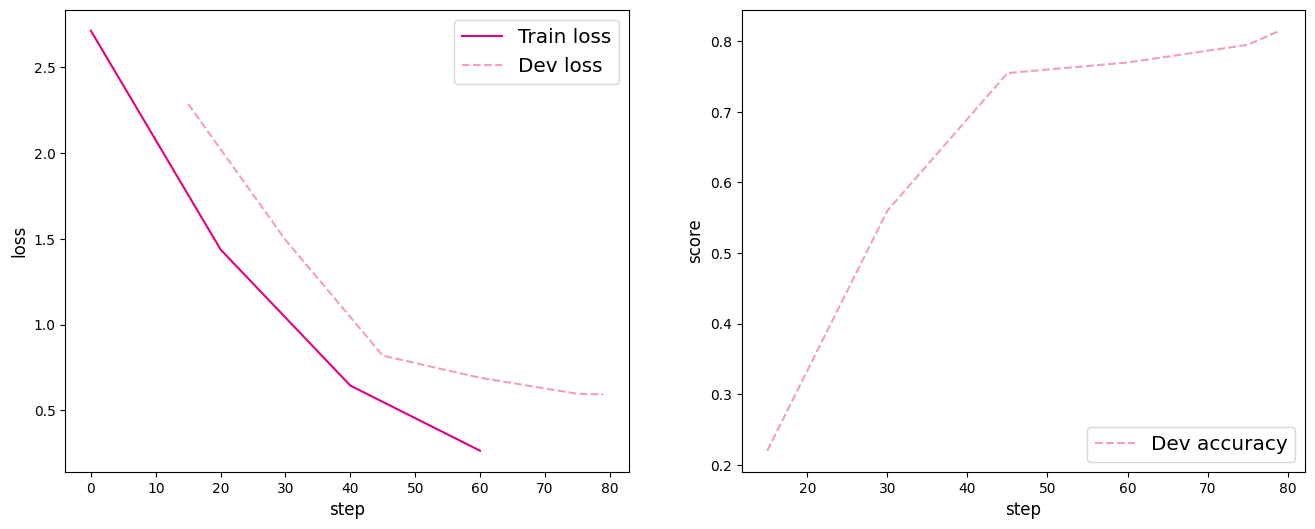

In [62]:
from nndl import plot

paddle.seed(100)
# 学习率大小
lr = 0.005  
# 批次大小
batch_size = 64
# 加载数据
train_loader = io.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = io.DataLoader(dev_dataset, batch_size=batch_size)
test_loader = io.DataLoader(test_dataset, batch_size=batch_size)
# 定义网络，不使用残差结构的深层网络
model = Model_ResNet18(in_channels=1, num_classes=10, use_residual=False)
# 定义优化器
optimizer = opt.SGD(learning_rate=lr, parameters=model.parameters())
# 实例化RunnerV3
runner = RunnerV3(model, optimizer, loss_fn, acc)
# 启动训练
log_steps = 15
eval_steps = 15
runner.train(train_loader, dev_loader, num_epochs=5, log_steps=log_steps, 
            eval_steps=eval_steps, save_path="best_model.pdparams")
# 可视化观察训练集与验证集的Loss变化情况
plot_training_loss_acc(runner, 'cnn-loss2.pdf')

#### 5.4.2.2 模型评价

使用测试数据对在训练过程中保存的最佳模型进行评价，观察模型在测试集上的准确率以及损失情况。代码实现如下

In [63]:
# 加载最优模型
runner.load_model('best_model.pdparams')
# 模型评价
score, loss = runner.evaluate(test_loader)
print("[Test] accuracy/loss: {:.4f}/{:.4f}".format(score, loss))

[Test] accuracy/loss: 0.8600/0.4903


/tmp/ipykernel_49966/4050099145.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image.astype('uint8'), mode='L')


从输出结果看，对比LeNet-5模型评价实验结果，网络层级加深后，训练效果不升反降。

### 5.4.3 带残差连接的ResNet18

#### 5.4.3.1 模型训练

使用带残差连接的ResNet18重复上面的实验，代码实现如下：

/tmp/ipykernel_49966/4050099145.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image.astype('uint8'), mode='L')
/hsiam02/huotao/miniconda3/envs/py312_paddle_gpu_3.2.0/lib/python3.12/site-packages/paddle/nn/layer/norm.py:818: UserWarning: When training, we now always track global mean and variance.
  warnings.warn(


[Train] epoch: 0/5, step: 0/80, loss: 3.65151
[Train] epoch: 0/5, step: 15/80, loss: 0.92804
[Evaluate]  dev score: 0.40000, dev loss: 1.76469
[Evaluate] best accuracy performence has been updated: 0.00000 --> 0.40000
[Train] epoch: 1/5, step: 30/80, loss: 0.17427
[Evaluate]  dev score: 0.80000, dev loss: 0.54894
[Evaluate] best accuracy performence has been updated: 0.40000 --> 0.80000
[Train] epoch: 2/5, step: 45/80, loss: 0.03893
[Evaluate]  dev score: 0.86500, dev loss: 0.44280
[Evaluate] best accuracy performence has been updated: 0.80000 --> 0.86500
[Train] epoch: 3/5, step: 60/80, loss: 0.02281
[Evaluate]  dev score: 0.85000, dev loss: 0.43444
[Train] epoch: 4/5, step: 75/80, loss: 0.00938
[Evaluate]  dev score: 0.86000, dev loss: 0.42953
[Evaluate]  dev score: 0.85000, dev loss: 0.42396
[Train] Training done!


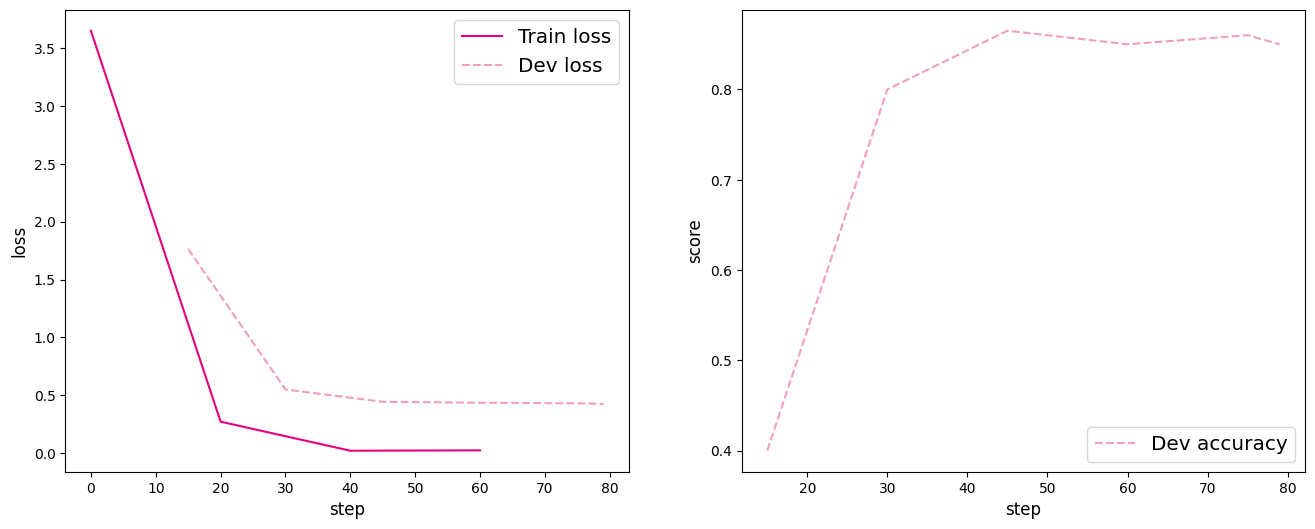

In [64]:
# 学习率大小
lr = 0.01  
# 批次大小
batch_size = 64
# 加载数据
train_loader = io.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = io.DataLoader(dev_dataset, batch_size=batch_size)
test_loader = io.DataLoader(test_dataset, batch_size=batch_size)
# 定义网络，通过指定use_residual为True，使用残差结构的深层网络
model = Model_ResNet18(in_channels=1, num_classes=10, use_residual=True)
# 定义优化器
optimizer = opt.SGD(learning_rate=lr, parameters=model.parameters())
# 实例化RunnerV3
runner = RunnerV3(model, optimizer, loss_fn, acc)
# 启动训练
log_steps = 15
eval_steps = 15
runner.train(train_loader, dev_loader, num_epochs=5, log_steps=log_steps, 
            eval_steps=eval_steps, save_path="best_model.pdparams")

# 可视化观察训练集与验证集的Loss变化情况
plot_training_loss_acc(runner, 'cnn-loss3.pdf')

#### 5.4.3.2 模型评价

使用测试数据对在训练过程中保存的最佳模型进行评价，观察模型在测试集上的准确率以及损失情况。

In [65]:
# 加载最优模型
runner.load_model('best_model.pdparams')
# 模型评价
score, loss = runner.evaluate(test_loader)
print("[Test] accuracy/loss: {:.4f}/{:.4f}".format(score, loss))

[Test] accuracy/loss: 0.8700/0.4415


/tmp/ipykernel_49966/4050099145.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image.astype('uint8'), mode='L')


添加了残差连接后，模型收敛曲线更平滑。
从输出结果看，和不使用残差连接的ResNet相比，添加了残差连接后，模型效果有了一定的提升。

### 5.4.4 与高层API实现版本的对比实验

对于Reset18这种比较经典的图像分类网络，飞桨高层API中都为大家提供了实现好的版本，大家可以不再从头开始实现。这里为高层API版本的resnet18模型和自定义的resnet18模型赋予相同的权重，并使用相同的输入数据，观察输出结果是否一致。

In [66]:
from paddle.vision.models import resnet18
import warnings
#warnings.filterwarnings("ignore")

# 使用飞桨HAPI中实现的resnet18模型，该模型默认输入通道数为3，输出类别数1000
hapi_model = resnet18()
# 自定义的resnet18模型
model = Model_ResNet18(in_channels=3, num_classes=1000, use_residual=True)

# 获取网络的权重
params = hapi_model.state_dict()
# 用来保存参数名映射后的网络权重
new_params = {}
# 将参数名进行映射
for key in params:
    if 'layer' in key:
        if 'downsample.0' in key:
            new_params['net.' + key[5:8] + '.shortcut' + key[-7:]] = params[key]
        elif 'downsample.1' in key:
            new_params['net.' + key[5:8] + '.shorcutt' + key[23:]] = params[key]
        else:
            new_params['net.' + key[5:]] = params[key]
    elif 'conv1.weight' == key:
        new_params['net.0.0.weight'] = params[key]
    elif 'bn1' in key:
        new_params['net.0.1' + key[3:]] = params[key]
    elif 'fc' in key:
        new_params['net.7' + key[2:]] = params[key]

# 将飞桨HAPI中实现的resnet18模型的权重参数赋予自定义的resnet18模型，保持两者一致
model.set_state_dict(new_params)

# 这里用np.random创建一个随机数组作为测试数据
inputs = np.random.randn(*[1,3,32,32])
inputs = inputs.astype('float32')
x = paddle.to_tensor(inputs)

output = model(x)
hapi_out = hapi_model(x)

# 计算两个模型输出的差异
diff = output - hapi_out
# 取差异最大的值
max_diff = paddle.max(diff)
print(max_diff)

/hsiam02/huotao/miniconda3/envs/py312_paddle_gpu_3.2.0/lib/python3.12/site-packages/paddle/nn/layer/layers.py:2274: UserWarning: Skip loading for net.0.0.bias. net.0.0.bias is not found in the provided dict.
  warnings.warn(f"Skip loading for {key}. " + str(err))
/hsiam02/huotao/miniconda3/envs/py312_paddle_gpu_3.2.0/lib/python3.12/site-packages/paddle/nn/layer/layers.py:2274: UserWarning: Skip loading for net.2.0.bn3.weight. net.2.0.bn3.weight is not found in the provided dict.
  warnings.warn(f"Skip loading for {key}. " + str(err))
/hsiam02/huotao/miniconda3/envs/py312_paddle_gpu_3.2.0/lib/python3.12/site-packages/paddle/nn/layer/layers.py:2274: UserWarning: Skip loading for net.2.0.bn3.bias. net.2.0.bn3.bias is not found in the provided dict.
  warnings.warn(f"Skip loading for {key}. " + str(err))
/hsiam02/huotao/miniconda3/envs/py312_paddle_gpu_3.2.0/lib/python3.12/site-packages/paddle/nn/layer/layers.py:2274: UserWarning: Skip loading for net.2.0.bn3._mean. net.2.0.bn3._mean is no

Tensor(shape=[], dtype=float32, place=Place(gpu:0), stop_gradient=False,
       0.)


可以看到，高层API版本的resnet18模型和自定义的resnet18模型输出结果是一致的，也就说明两个模型的实现完全一样。

## 5.5 实践：基于ResNet18网络完成图像分类任务

在本实践中，我们实践一个更通用的图像分类任务。

**图像分类**（Image Classification）是计算机视觉中的一个基础任务，将图像的语义将不同图像划分到不同类别。很多任务也可以转换为图像分类任务。比如人脸检测就是判断一个区域内是否有人脸，可以看作一个二分类的图像分类任务。

这里，我们使用的计算机视觉领域的经典数据集：CIFAR-10数据集，网络为ResNet18模型，损失函数为交叉熵损失，优化器为Adam优化器，评价指标为准确率。

*******

Adam优化器的介绍参考《神经网络与深度学习》第7.2.4.3节。

*******

### 5.5.1 数据处理

#### 5.5.1.1 数据集介绍

CIFAR-10数据集包含了10种不同的类别、共60,000张图像，其中每个类别的图像都是6000张，图像大小均为$32\times32$像素。CIFAR-10数据集的示例如 **图5.15** 所示。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/12cb79a15a3d40fa9b0124dfe4681ab8b60b82d067fb433eb6da600b7c2ec875" width="600" hegiht="" ></center>
<center><br>图5.15：CIFAR-10数据集示例</br></center>
<br></br>

将数据集文件进行解压：

In [ ]:
# 解压数据集
# 初次运行时将注释取消，以便解压文件
# 如果已经解压过，不需要运行此段代码，否则由于文件已经存在，解压时会报错
# !tar -xvf /home/aistudio/data/data9154/cifar-10-python.tar.gz -C /home/aistudio/datasets/

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


#### 5.5.1.2 数据读取

在本实验中，将原始训练集拆分成了train_set、dev_set两个部分，分别包括40 000条和10 000条样本。将data_batch_1到data_batch_4作为训练集，data_batch_5作为验证集，test_batch作为测试集。
最终的数据集构成为：

* 训练集：40 000条样本。
* 验证集：10 000条样本。
* 测试集：10 000条样本。

读取一个batch数据的代码如下所示：

In [2]:
import os
import pickle
import numpy as np

def load_cifar10_batch(folder_path, batch_id=1, mode='train'):
    if mode == 'test':
        file_path = os.path.join(folder_path, 'test_batch')
    else:
        file_path = os.path.join(folder_path, 'data_batch_'+str(batch_id))

    #加载数据集文件
    with open(file_path, 'rb') as batch_file:
        batch = pickle.load(batch_file, encoding = 'latin1')

    imgs = batch['data'].reshape((len(batch['data']),3,32,32)) / 255.
    labels = batch['labels']

    return np.array(imgs, dtype='float32'), np.array(labels)

imgs_batch, labels_batch = load_cifar10_batch(folder_path='datasets/cifar-10-batches-py', 
                                                batch_id=1, mode='train')


查看数据的维度：

In [3]:
#打印一下每个batch中X和y的维度
print ("batch of imgs shape: ",imgs_batch.shape, "batch of labels shape: ", labels_batch.shape)

batch of imgs shape:  (10000, 3, 32, 32) batch of labels shape:  (10000,)


可视化观察其中的一张样本图像和对应的标签，代码如下所示：

The label in the picture is 9


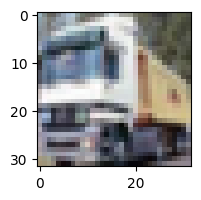

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

image, label = imgs_batch[1], labels_batch[1]
print("The label in the picture is {}".format(label))
plt.figure(figsize=(2, 2))
plt.imshow(image.transpose(1,2,0))
plt.savefig('cnn-car.pdf')

#### 5.5.1.3 构造Dataset类

构造一个CIFAR10Dataset类，其将继承自`paddle.io.DataSet`类，可以逐个数据进行处理。代码实现如下：

In [6]:
import paddle
import paddle.io as io
from paddle.vision.transforms import Normalize

class CIFAR10Dataset(io.Dataset):
    def __init__(self, folder_path='/home/aistudio/cifar-10-batches-py', mode='train'):
        if mode == 'train':
            #加载batch1-batch4作为训练集
            self.imgs, self.labels = load_cifar10_batch(folder_path=folder_path, batch_id=1, mode='train')
            for i in range(2, 5):
                imgs_batch, labels_batch = load_cifar10_batch(folder_path=folder_path, batch_id=i, mode='train')
                self.imgs, self.labels = np.concatenate([self.imgs, imgs_batch]), np.concatenate([self.labels, labels_batch])
        elif mode == 'dev':
            #加载batch5作为验证集
            self.imgs, self.labels = load_cifar10_batch(folder_path=folder_path, batch_id=5, mode='dev')
        elif mode == 'test':
            #加载测试集
            self.imgs, self.labels = load_cifar10_batch(folder_path=folder_path, mode='test')
        self.transform = Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010], data_format='CHW')

    def __getitem__(self, idx):
        img, label = self.imgs[idx], self.labels[idx]
        img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.imgs)

paddle.seed(100)
train_dataset = CIFAR10Dataset(folder_path='datasets/cifar-10-batches-py', mode='train')
dev_dataset = CIFAR10Dataset(folder_path='datasets/cifar-10-batches-py', mode='dev')
test_dataset = CIFAR10Dataset(folder_path='datasets/cifar-10-batches-py', mode='test')

### 5.5.2 模型构建

使用飞桨高层API中的Resnet18进行图像分类实验。

In [7]:
from paddle.vision.models import resnet18

resnet18_model = resnet18()

W1022 09:48:46.833032 52139 gpu_resources.cc:114] Please NOTE: device: 0, GPU Compute Capability: 8.0, Driver API Version: 12.4, Runtime API Version: 11.8


******

飞桨高层 API是对飞桨API的进一步封装与升级，提供了更加简洁易用的API，进一步提升了飞桨的易学易用性。其中，飞桨高层API封装了以下模块：
1. Model类，支持仅用几行代码完成模型的训练；
1. 图像预处理模块，包含数十种数据处理函数，基本涵盖了常用的数据处理、数据增强方法；
1. 计算机视觉领域和自然语言处理领域的常用模型，包括但不限于mobilenet、resnet、yolov3、cyclegan、bert、transformer、seq2seq等等，同时发布了对应模型的预训练模型，可以直接使用这些模型或者在此基础上完成二次开发。
  
飞桨高层 API主要包含在`paddle.vision`和`paddle.text`目录中。

******

### 5.5.3 模型训练

复用RunnerV3类，实例化RunnerV3类，并传入训练配置。
使用训练集和验证集进行模型训练，共训练30个epoch。
在实验中，保存准确率最高的模型作为最佳模型。代码实现如下：

In [9]:
import paddle.nn.functional as F
import paddle.optimizer as opt
from nndl import RunnerV3, metric 

#指定运行设备
use_gpu = True if paddle.get_device().startswith("gpu") else False
if use_gpu:
    paddle.set_device('gpu:0')
#学习率大小
lr = 0.001  
#批次大小
batch_size = 64 
#加载数据
train_loader = io.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = io.DataLoader(dev_dataset, batch_size=batch_size)
test_loader = io.DataLoader(test_dataset, batch_size=batch_size) 
#定义网络
model = resnet18_model
#定义优化器，这里使用Adam优化器以及l2正则化策略，相关内容在7.3.3.2和7.6.2中会进行详细介绍
optimizer = opt.Adam(learning_rate=lr, parameters=model.parameters(), weight_decay=0.005)
#定义损失函数
loss_fn = F.cross_entropy
#定义评价指标
metric = metric.Accuracy(is_logist=True)
#实例化RunnerV3
runner = RunnerV3(model, optimizer, loss_fn, metric)
#启动训练
log_steps = 3000
eval_steps = 3000
runner.train(train_loader, dev_loader, num_epochs=30, log_steps=log_steps, 
                eval_steps=eval_steps, save_path="best_model.pdparams")

                

W1022 09:51:41.211890 52139 gpu_resources.cc:243] WARNING: device: 0. The installed Paddle is compiled with CUDNN 8.9, but CUDNN version in your machine is 8.9, which may cause serious incompatible bug. Please recompile or reinstall Paddle with compatible CUDNN version.
/hsiam02/huotao/miniconda3/envs/py312_paddle_gpu_3.2.0/lib/python3.12/site-packages/paddle/nn/layer/norm.py:818: UserWarning: When training, we now always track global mean and variance.
  warnings.warn(


[Train] epoch: 0/30, step: 0/18750, loss: 7.42867
[Train] epoch: 4/30, step: 3000/18750, loss: 1.00335
[Evaluate]  dev score: 0.66080, dev loss: 0.99045
[Evaluate] best accuracy performence has been updated: 0.00000 --> 0.66080
[Train] epoch: 9/30, step: 6000/18750, loss: 0.50673
[Evaluate]  dev score: 0.70930, dev loss: 0.86414
[Evaluate] best accuracy performence has been updated: 0.66080 --> 0.70930
[Train] epoch: 14/30, step: 9000/18750, loss: 0.48521
[Evaluate]  dev score: 0.72530, dev loss: 0.82281
[Evaluate] best accuracy performence has been updated: 0.70930 --> 0.72530
[Train] epoch: 19/30, step: 12000/18750, loss: 0.61735
[Evaluate]  dev score: 0.71250, dev loss: 0.88534
[Train] epoch: 24/30, step: 15000/18750, loss: 0.48406
[Evaluate]  dev score: 0.74000, dev loss: 0.79032
[Evaluate] best accuracy performence has been updated: 0.72530 --> 0.74000
[Train] epoch: 28/30, step: 18000/18750, loss: 0.58887
[Evaluate]  dev score: 0.72330, dev loss: 0.84283
[Evaluate]  dev score: 0.

可视化观察训练集与验证集的准确率及损失变化情况。

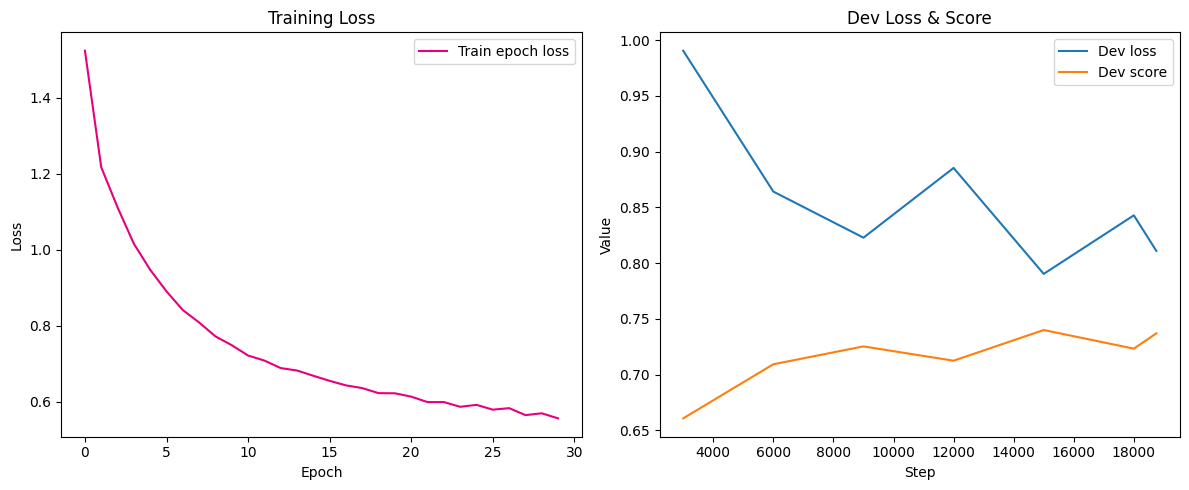

In [11]:
import matplotlib.pyplot as plt

def plot_runner_v3(runner, fig_name="runner_plot.pdf"):
    plt.figure(figsize=(12,5))

    # 训练 epoch loss
    plt.subplot(1,2,1)
    epochs = list(range(len(runner.train_epoch_losses)))
    plt.plot(epochs, runner.train_epoch_losses, color='#e4007f', label="Train epoch loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()

    # 验证 loss & score
    plt.subplot(1,2,2)
    steps = [s for s,_ in runner.dev_losses]
    losses = [l for _,l in runner.dev_losses]
    scores = runner.dev_scores
    plt.plot(steps, losses, label="Dev loss")
    plt.plot(steps, scores, label="Dev score")
    plt.xlabel("Step")
    plt.ylabel("Value")
    plt.title("Dev Loss & Score")
    plt.legend()

    plt.tight_layout()
    plt.savefig(fig_name)
    plt.show()




plot_runner_v3(runner, fig_name="cnn-loss4.pdf")


*******

在本实验中，使用了第7章中介绍的Adam优化器进行网络优化，如果使用SGD优化器，会造成过拟合的现象，在验证集上无法得到很好的收敛效果。可以尝试使用第7章中其他优化策略调整训练配置，达到更高的模型精度。

*******

### 5.5.4 模型评价

使用测试数据对在训练过程中保存的最佳模型进行评价，观察模型在测试集上的准确率以及损失情况。代码实现如下：

In [12]:
# 加载最优模型
runner.load_model('best_model.pdparams')
# 模型评价
score, loss = runner.evaluate(test_loader)
print("[Test] accuracy/loss: {:.4f}/{:.4f}".format(score, loss))

[Test] accuracy/loss: 0.7359/0.8073


### 5.5.5 模型预测

同样地，也可以使用保存好的模型，对测试集中的数据进行模型预测，观察模型效果，具体代码实现如下：

The true category is 8 and the predicted category is 8


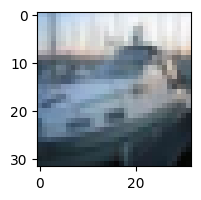

In [15]:
#获取测试集中的一个batch的数据
X, labels = next(iter(test_loader))
logits = runner.predict(X)
#多分类，使用softmax计算预测概率
pred = F.softmax(logits)
#获取概率最大的类别
pred_class = paddle.argmax(pred[2]).numpy()
label = labels[2].item()
#输出真实类别与预测类别
print(f"The true category is {label} and the predicted category is {pred_class}")
#可视化图片
plt.figure(figsize=(2, 2))
imgs, labels = load_cifar10_batch(folder_path='datasets/cifar-10-batches-py', mode='test')
plt.imshow(imgs[2].transpose(1,2,0))
plt.savefig('cnn-test-vis.pdf')